# Setup

In [1]:
import numpy as np, timeit, time, matplotlib.pyplot as plt, json, os
from tqdm import tqdm

In [2]:
from binary_models import *
from benchmark_models import get_SMK_SCM, vectorized_SMK_model
from benchmark_models import nSMK_model, get_avg_nSMK_SCM, get_lucb_nSMK_SCM
from evaluation import evaluate_full
# from actualcauses import beam_search, show_rules, iterative_identification
# from actualcauses.base_algorithm import *
from actualcauses_local.base_algorithm import beam_search, get_rules, get_initial_rules
from actualcauses_local.lucb import *
from actualcauses_local.iterative_subinstance_algorithm import iterative_identification as isi
from general import *

In [3]:
from experiments import run_noisy_SMK

In [4]:
np.set_printoptions(suppress=True)

# Functions

In [5]:
def var2label(S, variables):
    return {variables[i] for i in S}

In [6]:
def get_data_n_attacker(n):
    with open("../results/base-exact/structured.json") as file:
        data = json.load(file)
    for data_attacker in data:
        if data_attacker["n_attacker"] == n:
            return data_attacker["results"]
    raise f"{n=} not found"

In [7]:
def get_ref(n=5, instance_id=0):
    data = json.load(open("../results/base-exact/structured.json"))
    for dat_attacker in data:
        if dat_attacker["n_attacker"] == n:
            break
    else:
        raise f"{n=} not found"
    exact_res = dat_attacker["results"]
    
    u = exact_res[instance_id]["context"]
    exact_causes = exact_res[instance_id]["causes"]
    exact_e = exact_res[instance_id]["rules"]
    return u, exact_causes, exact_e

In [8]:
def find_eps(n, u, N, nl, r=3):
    t = nl / len(get_SMK_V(n))
    S = vectorized_SMK_model(u, [{}], n, N, t)
    phi_values = S[:,-1]
    return float(phi_values.mean().round(r))

In [9]:
def test_context_multi_seeds(n, n_seeds, lucb_params):
    # exact_res = get_data_n_attacker(n)
    contexts = np.load(f"../results/contexts/n_attacker={n}.npy")

    evals = []
    for instance_id, u in enumerate(contexts[:10]):
        # u = instance["context"]
        
        scm = get_SMK_SCM(n, u)
        scm.find_causes(max_steps=4, beam_size=bs,verbose=0)
        det_causes = scm.causes_hashable
        scm.find_causes(ISI=True, max_steps=7, beam_size=-1, verbose=0)
        ref_causes = scm.causes_hashable
        det_eval = evaluate_full(det_causes, ref_causes)
        if det_eval["F1"] < .05: continue 
        print(f"Deterministic: {det_eval["F1"]:.2%}", end=" / ")

        eval_list = []
        eval_times = []
        for seed in tqdm(range(n_seeds)):
            SCM_avg = get_avg_nSMK_SCM(n, u, lucb_params["max_iter"], nl)
            SCM_avg.find_causes(max_steps=7, beam_size=bs, verbose=0, epsilon=eps)
            avg_eval = evaluate_full(SCM_avg.causes_hashable, ref_causes)
    
            SCM_lucb = get_lucb_nSMK_SCM(n, u, nl, lucb_params|{"verbose":0})
            SCM_lucb.find_causes(max_steps=7, beam_size=bs, verbose=0, epsilon=eps)
            lucb_eval = evaluate_full(SCM_lucb.causes_hashable, ref_causes)
            eval_list.append((avg_eval["F1"], lucb_eval["F1"]))
            eval_times.append((SCM_avg.identification_time, SCM_lucb.identification_time))
        eval_list = np.array(eval_list)
        eval_times = np.array(eval_times)
        
        print(f"Naive: {eval_list[:,0].mean():.2%}±{eval_list[:,0].std():.2%} ({eval_times[:,0].mean():.2f}±{eval_times[:,0].std():.2f})", end=" / ")
        print(f"LUCB: {eval_list[:,1].mean():.2%}±{eval_list[:,1].std():.2%} ({eval_times[:,1].mean():.2f}±{eval_times[:,1].std():.2f})")
        print()
        evals.append(eval_list.mean(0))
    evals = np.array(evals)
    print(f"Naive: {evals[:,0].mean():.2%}±{evals[:,0].std():.2%} / LUCB: {evals[:,1].mean():.2%}±{evals[:,1].std():.2%}")

In [10]:
def interpolate(x, vmin=None, vmax=None, vrefs=None):
    # return x
    if vrefs is not None:
        vmin = np.min(vrefs)
        vmax = np.max(vrefs)
    else:
        if vmin is None:
            vmin = np.min(x)
        if vmax is None:
            vmax = np.max(x)
    
    if vmin == vmax: return x
    return (x - vmin) / (vmax - vmin)

# Main

Problem to solve: for 5/10 attackers, LUCB misses way more than naive sampling

In [23]:
n = 2
variables = get_SMK_V(n)

bs = 12
max_iter = 100
# test_eps_iter = int(1e4)
contexts = np.load(f"../results/contexts/n_attacker={n}.npy")
u = contexts[0]
# eps = find_eps(n, u, test_eps_iter, nl) - .1
eps=.65
nl = 1.5
lucb_params = {"beam_size": bs, "a": eps, 
               "cause_eps": .1, 
               "non_cause_eps": .1, 
               "beam_eps": .1, 
               "max_iter": max_iter, 
               "verbose": 2, 
               "init_batch_size": 30,
               "batch_size": 5,
               "delta": .05
               }
lucb_params["init_batch_size"], lucb_params["batch_size"], eps

(30, 5, 0.65)

## Granular tests

In [24]:
scm = get_SMK_SCM(n, u)
scm.find_causes(ISI=True, beam_size=-1, max_steps=7, verbose=0)
scm.show_indentification_result()

Identification time: 0.003s

C={'A-U1': '0'}, W={}, output=0, score=6.000
C={'AD-U1': '0'}, W={}, output=0, score=6.000
C={'KMS-U1': '0'}, W={}, output=0, score=7.000
C={'SD-U1': '0'}, W={}, output=0, score=8.000
C={'SD': '0'}, W={}, output=0, score=9.000


In [25]:
# Build rules and refs
rules_1 = get_initial_rules(scm.V[:-1],scm.D[:-1], scm.v[:-1])
rules_2 = get_rules(rules_1, scm.V[:-1],scm.D[:-1],scm.v[:-1], [], dict(zip(scm.V, scm.v)))
rules = rules_2
x = np.arange(len(rules))
ref_out = scm.apply_interventions(rules)
ref_psi = np.array([elt[2]/len(scm.V) for elt in ref_out])
ref_phi = np.array([elt[1] for elt in ref_out])
sorted_ids_phi = np.argsort(ref_phi)
sorted_ids_psi = np.argsort(ref_psi)

# Compute average
scm_avg = get_avg_nSMK_SCM(n, u, max_iter, nl)
out_avg = scm_avg.apply_interventions(rules)
avg_psi = np.array([elt[2]/len(scm_avg.V) for elt in out_avg])
avg_phi = np.array([elt[1] for elt in out_avg])

# Compute lucb
scm_lucb = get_lucb_nSMK_SCM(n, u, nl,lucb_params|{"verbose":2})
out_lucb = scm_lucb.apply_interventions(rules)
lucb_psi = np.array([elt[2] for elt in out_lucb])
lucb_phi = np.array([elt[1] for elt in out_lucb])
lucb_iter = np.array([elt[0][-1] for elt in out_lucb])

 48%|████▊     | 39715.0/82800 [00:00<00:00, 163427.53it/s]

828, 0, 0, 0, 
88, 673, 12, 661, 
74, 420, 12, 662, 
60, 341, 12, 662, 
58, 287, 12, 662, 


 65%|██████▌   | 53985.0/82800 [00:00<00:00, 115349.88it/s]

49, 287, 12, 662, 
40, 261, 12, 662, 
37, 224, 12, 662, 
32, 199, 12, 662, 
23, 180, 12, 662, 
Success: beam_bound=0.0855 / cause_bound=0.0340 / non_cause_bound=0.0962)


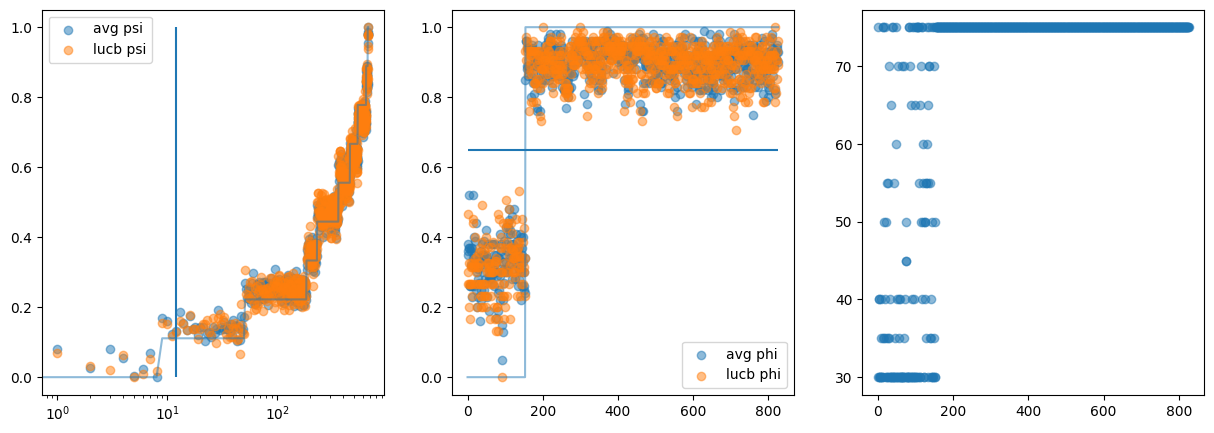

In [26]:
_, axes = plt.subplots(1,3,figsize=(15,5))
max_x = -1

plot_ids_psi = [i for i in sorted_ids_psi if ref_phi[i] == 1][:max_x]

def filter_psi(values):
    values = interpolate(values[plot_ids_psi])
    return np.arange(len(values)), values

alpha = .5
# Plot refs
axes[0].plot(*filter_psi(ref_psi), alpha=alpha)#, c=c)
axes[1].plot(ref_phi[sorted_ids_phi][:max_x], alpha=alpha)#, c=c)

axes[0].vlines(bs, 0, 1)
axes[1].hlines(eps, 0, len(rules[:max_x]))

# Average
axes[0].scatter(*filter_psi(avg_psi), alpha=alpha, label="avg psi")#, c=avg_colors[plot_ids_psi])
axes[1].scatter(x[:max_x], avg_phi[sorted_ids_phi][:max_x], alpha=alpha, label="avg phi")

# LUCB
axes[0].scatter(*filter_psi(lucb_psi), alpha=alpha, label="lucb psi")#, c=lucb_colors[plot_ids_psi])
axes[1].scatter(x[:max_x], lucb_phi[sorted_ids_phi][:max_x], alpha=alpha, label="lucb phi")
axes[2].scatter(x[:max_x], lucb_iter[sorted_ids_phi][:max_x], alpha=alpha)


axes[0].set_xscale('log')
axes[0].legend()
# axes[1].set_xscale('log')
axes[1].legend()
# axes[2].set_xscale('log')

(140.0, 160.0)

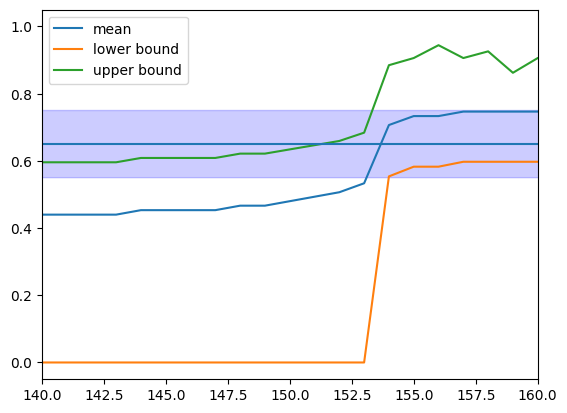

In [27]:
lucb_phi = np.array([elt[1] for elt in out_lucb])
lucb_ub = np.array([elt[0][1] for elt in out_lucb])
lucb_lb = np.array([elt[0][2] for elt in out_lucb])
sorted_lucb_ids = np.argsort(lucb_phi)
plt.plot(lucb_phi[sorted_lucb_ids], label="mean")
plt.plot(lucb_lb[sorted_lucb_ids], label="lower bound")
plt.plot(lucb_ub[sorted_lucb_ids], label="upper bound")
plt.fill_between(x, 
                 np.full(len(x), eps) - lucb_params["cause_eps"], 
                 np.full(len(x), eps) + lucb_params["non_cause_eps"], 
                 color='blue', alpha=0.2)
plt.hlines(eps, 0, len(rules))
plt.legend()
# plt.xscale('log')
plt.xlim(140,160)

max_ub_beam=1.00, min_lb_non_meam=0.38


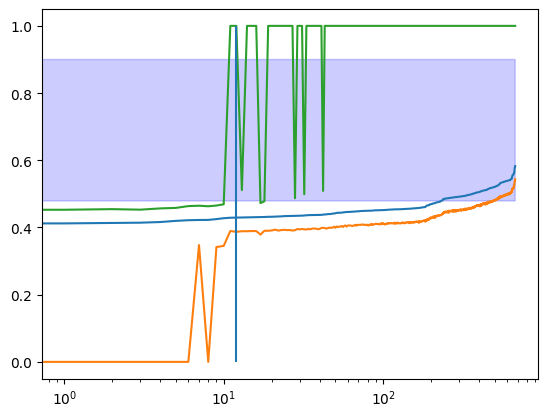

In [28]:

lucb_ub = np.array([elt[0][6] for elt in out_lucb])
lucb_lb = np.array([elt[0][7] for elt in out_lucb])
sorted_lucb_ids = np.argsort(lucb_psi)
sorted_lucb_ids = [ i for i in sorted_lucb_ids if lucb_phi[i] >= eps]
x_psi = np.arange(len(sorted_lucb_ids))
plt.plot(lucb_psi[sorted_lucb_ids])
plt.plot(lucb_lb[sorted_lucb_ids])
plt.plot(lucb_ub[sorted_lucb_ids])

# cancel_ids = lucb_phi < eps
# non_cause_ids = np.argwhere(~cancel_ids).flatten()
sorted_non_cause_ids = sorted_lucb_ids
beam_ids = np.array(sorted_non_cause_ids[:bs])
non_beam_ids = np.array(sorted_non_cause_ids[bs:])
ut = beam_ids[np.argmax(lucb_ub[beam_ids])]
lt = non_beam_ids[np.argmin(lucb_lb[non_beam_ids])]
max_ub_beam = lucb_ub[ut]
min_lb_non_meam = lucb_lb[lt]
print(f"{max_ub_beam=:.2f}, {min_lb_non_meam=:.2f}")
min_eps = max_ub_beam - lucb_params["beam_eps"]
max_eps = min_lb_non_meam + lucb_params["beam_eps"]

plt.fill_between(x_psi, 
                 np.full(len(x_psi), min_eps), 
                 np.full(len(x_psi), max_eps),
                 color='blue', alpha=0.2)
# ids_overlapping = lucb_ub[beam_ids] >= lucb_lb[lt] - lucb_params["beam_eps"] 
# beam_overlap = beam_ids[ids_overlapping]
# plt.scatter(np.array(sorted_non_cause_ids)[beam_overlap], lucb_psi[sorted_non_cause_ids][beam_overlap])
plt.vlines(bs, 0, 1)
plt.xscale('log')
# plt.ylim(.35,.6)

In [ ]:
beam_overlap

In [ ]:
print(lucb_psi[beam_ids])
print(lucb_ub[beam_ids])

In [ ]:
lucb_v = np.array([elt[0][6] for elt in out_lucb])

## General tests

In [ ]:
# test_context_multi_seeds(n, n_seeds, lucb_params)

## Single overall test

In [ ]:
# ref_causes = list(map(tuple,exact_causes))

In [ ]:
# SCM_avg = get_avg_nSMK_SCM(n, u, N, nl)
# SCM_lucb = get_lucb_nSMK_SCM(n, u, nl, lucb_params)
# scm = get_SMK_SCM(n, u)

In [ ]:
# np.random.seed(42)
# output_avg = beam_search(**SCM_avg.get_input(), max_steps=4, beam_size=bs,verbose=2, epsilon=eps)
# print("\nRESULTS\n")
# show_rules(output_avg, SCM_avg.V)

In [ ]:
# np.random.seed(42)
# output_lucb = beam_search(**SCM_lucb.get_input(), max_steps=4, beam_size=bs,verbose=2, epsilon=eps)
# print("\nRESULTS\n")
# show_rules(output_lucb, SCM_lucb.V)

In [ ]:
# avg_causes = [tuple(elt[3]) for elt in output_avg]
# lucb_causes = [tuple(elt[3]) for elt in output_lucb]
# avg_F1 = evaluate_full(avg_causes, ref_causes)["F1"]
# lucb_F1 = evaluate_full(lucb_causes, ref_causes)["F1"]
# print(f"Naive: {avg_F1:.2f} / LUCB: {lucb_F1:.2f}")